### Compute VB index with hindcast data

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.decomposition import PCA
import scipy.signal as signal
import statsmodels.api as sm
import pandas as pd
from seaborn import regplot
from seaborn import heatmap

In [2]:
def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['latitude']))
    weighted_da = da * weights
    return weighted_da


def reshape_to_2d(da):
    """Reshape (lat, lon, sample) data into 2D matrix (space x sample)."""
    space_dim = da['latitude'].size * da['longitude'].size
    ##modify here likely!
    reshaped = da.stack(space=('latitude', 'longitude')).transpose('sample', 'space')
    return reshaped


def compute_covariance_matrix(reshaped_da):
    """Compute the covariance matrix of the data."""
    data = reshaped_da.values
    data = data - np.nanmean(data, axis=0)  # Centering the data
    covariance_matrix = np.cov(data.T)
    return covariance_matrix


def perform_svd(cov_matrix):
    """Perform SVD on the covariance matrix."""
    U, S, Vt = np.linalg.svd(cov_matrix)
    return U, S, Vt


def plot_first_principal_component(reshaped_da, Vt):
    """Plot the first principal component as a map."""
    first_pc = Vt[0, :] #first eigenvector with largest eigenvalue
    pc_map = reshaped_da.isel(time=0).copy() #.isel selects the i you give, make a copy of given array at i
    pc_map.values = first_pc #change the values from before to the first_pc values
    pc_map_unstacked = pc_map.unstack('space')

    plt.figure(figsize=(8, 5))
    pc_map_unstacked.plot(cmap='RdBu')
    plt.title("First Principal Component (Spatial Pattern)")
    plt.show()

    return pc_map_unstacked


def compute_zonal_mean(pc_map_unstacked):
    """Compute the zonal mean of the first principal component map."""
    zonal_mean = pc_map_unstacked.mean(dim='longitude')
    return zonal_mean


def make_zonal_mean_map(zonal_mean, da):
    """Create a zonal mean map, assigning each longitude the same value."""
    zonal_map = xr.zeros_like(da.isel(time=0)) #blank map with same dimensions as da
    for lon in zonal_map['longitude']:
        zonal_map.loc[{'longitude': lon}] = zonal_mean #assign zonal mean value to each longitude
    return zonal_map


def regress_onto_zonal_mean_map(da, zonal_map):
    """Regress original data onto the zonal mean map (time series of coefficients)."""
#flattening data
    zonal_map_flat = zonal_map.stack(space=('latitude', 'longitude')).values
    data_flat = da.stack(space=('latitude', 'longitude')).transpose('sample', 'space').values
#detrending by removing mean
    zonal_map_flat = zonal_map_flat - np.nanmean(zonal_map_flat)
    data_flat = data_flat - np.nanmean(data_flat, axis=0)

    regression_coefficients = np.dot(data_flat, zonal_map_flat) / np.dot(zonal_map_flat, zonal_map_flat)

    return regression_coefficients


def plot_regression_coefficients(time, regression_coefficients):
    """Plot regression coefficients over time."""
    plt.figure(figsize=(8, 5))
    plt.plot(time, regression_coefficients, label='Regression Coefficients')
    plt.xlabel('Time')
    plt.ylabel('Coefficient')
    plt.title('Regression Coefficients Over Time')
    plt.grid()
    plt.show()
        


def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['latitude']))
    weighted_da = da * weights
    return weighted_da


def reshape_to_2d(da):
    """Reshape (lat, lon, sample) data into 2D matrix (space x sample)."""
    space_dim = da['latitude'].size * da['longitude'].size
    ##modify here likely!
    reshaped = da.stack(space=('latitude', 'longitude')).transpose('sample', 'space')
    return reshaped


def compute_covariance_matrix(reshaped_da):
    """Compute the covariance matrix of the data."""
    data = reshaped_da.values
    data = data - np.nanmean(data, axis=0)  # Centering the data
    covariance_matrix = np.cov(data.T)
    return covariance_matrix


def perform_svd(cov_matrix):
    """Perform SVD on the covariance matrix."""
    U, S, Vt = np.linalg.svd(cov_matrix)
    return U, S, Vt


def plot_first_principal_component(reshaped_da, Vt):
    """Plot the first principal component as a map."""
    first_pc = Vt[0, :] #first eigenvector with largest eigenvalue
    pc_map = reshaped_da.isel(time=0).copy() #.isel selects the i you give, make a copy of given array at i
    pc_map.values = first_pc #change the values from before to the first_pc values
    pc_map_unstacked = pc_map.unstack('space')

    plt.figure(figsize=(8, 5))
    pc_map_unstacked.plot(cmap='RdBu')
    plt.title("First Principal Component (Spatial Pattern)")
    plt.show()

    return pc_map_unstacked


def compute_zonal_mean(pc_map_unstacked):
    """Compute the zonal mean of the first principal component map."""
    zonal_mean = pc_map_unstacked.mean(dim='longitude')
    return zonal_mean


def make_zonal_mean_map(zonal_mean, da):
    """Create a zonal mean map, assigning each longitude the same value."""
    zonal_map = xr.zeros_like(da.isel(time=0)) #blank map with same dimensions as da
    for lon in zonal_map['longitude']:
        zonal_map.loc[{'longitude': lon}] = zonal_mean #assign zonal mean value to each longitude
    return zonal_map


def regress_onto_zonal_mean_map(da, zonal_map):
    """Regress original data onto the zonal mean map (time series of coefficients)."""
#flattening data
    zonal_map_flat = zonal_map.stack(space=('latitude', 'longitude')).values
    data_flat = da.stack(space=('latitude', 'longitude')).transpose('sample', 'space').values
#detrending by removing mean
    zonal_map_flat = zonal_map_flat - np.nanmean(zonal_map_flat)
    data_flat = data_flat - np.nanmean(data_flat, axis=0)

    regression_coefficients = np.dot(data_flat, zonal_map_flat) / np.dot(zonal_map_flat, zonal_map_flat)

    return regression_coefficients


def plot_regression_coefficients(time, regression_coefficients):
    """Plot regression coefficients over time."""
    plt.figure(figsize=(8, 5))
    plt.plot(time, regression_coefficients, label='Regression Coefficients')
    plt.xlabel('Time')
    plt.ylabel('Coefficient')
    plt.title('Regression Coefficients Over Time')
    plt.grid()
    plt.show()
        


def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def select_region(ds, lat_min, lat_max, lon_min, lon_max):
    """
    Select a latitude-longitude box.

    Works even if latitude is ordered north-to-south, as in ERA5/SEAS5:
        90, 89, 88, ..., -90

    Longitude in your dataset is 0 to 360.
    So:
        -76 to -70 becomes 284 to 290
        -62 to -49 becomes 298 to 311
    """

    lat = ds["latitude"]

    # If latitude is decreasing: 90, 89, ..., -90
    if lat[0] > lat[-1]:
        lat_slice = slice(lat_max, lat_min)
    else:
        lat_slice = slice(lat_min, lat_max)

    out = ds.sel(
        latitude=lat_slice,
        longitude=slice(lon_min, lon_max)
    )

    return out

def compute_sample_anomaly(ds):
    """
    Compute anomaly across all samples.

    For each grid point:
        anomaly = value - mean over samples

    This keeps all ensemble members and all years.
    """

    return ds - ds.mean(dim="sample")

def detrend_across_time(ds):
    """
    Remove a linear trend across time.

    Important:
    Your dimension is called 'sample', not 'time'.

    Each sample has a coordinate called 'forecast_reference_time'.
    We extract the year from that coordinate and regress each grid point
    against year.

    Because you have 51 ensemble members per year, the same year appears
    many times. That is okay: the trend is fitted across all samples.
    """

    # Extract year from forecast_reference_time
    years = xr.DataArray(
        ds["forecast_reference_time"].dt.year.values,
        dims="sample",
        coords={"sample": ds["sample"]},
        name="year"
    )

    # Center the year to make the regression numerically cleaner
    x = years - years.mean(dim="sample")

    # Output container
    detrended_vars = {}

    for var in ds.data_vars:

        y = ds[var]

        # Mean over sample
        y_mean = y.mean(dim="sample")

        # Linear regression slope:
        # slope = cov(x, y) / var(x)
        slope = ((x * (y - y_mean)).mean(dim="sample")) / ((x ** 2).mean(dim="sample"))

        # Fitted linear trend
        fit = y_mean + slope * x

        # Remove fitted trend
        detrended_vars[var] = y - fit

    out = xr.Dataset(detrended_vars, coords=ds.coords)

    return out


def spatial_average(ds):
    """
    Latitude-weighted spatial average.

    Output:
        one value per sample
    """

    weights = np.cos(np.deg2rad(ds["latitude"]))

    out = ds.weighted(weights).mean(dim=["latitude", "longitude"])

    return out

def standardize(ds):
    """
    Standardize each variable across samples.

    z = value / std

    The mean should already be near zero after anomaly + detrending.
    If you want strict z-score, use:
        (ds - ds.mean("sample")) / ds.std("sample")
    """

    return ds / ds.std(dim="sample")

def process_region(ds_season, lat_min, lat_max, lon_min, lon_max):
    """
    Full pipeline for one region and one season.

    Input:
        ds_season = SON_mean or DJF_mean

    Output:
        standardized anomaly time series for all samples
    """

    # 1. Select region
    region = select_region(
        ds_season,
        lat_min=lat_min,
        lat_max=lat_max,
        lon_min=lon_min,
        lon_max=lon_max
    )

    # 2. Anomaly over samples
    region_an = compute_sample_anomaly(region)

    # 3. Remove linear trend across time/sample
    region_detr = detrend_across_time(region_an)

    # 4. Spatial average
    region_avg = spatial_average(region_detr)

    # 5. Standardize
    region_std = standardize(region_avg)

    return region_std




In [3]:
# Path to your NetCDF file
DATADIR='/climca/data/SEAS5_SA/data'

# Open the dataset
# chunks is useful because your dataset is huge.
# It avoids loading everything into memory immediately.
u_data_daily1=xr.open_dataset(DATADIR+'/seas5_daily_u_component_wind_50hPa_SepInit.nc', 
                       chunks={'number':1, 'forecast_reference_time':10, 'forecastMonth':6})

print(u_data_daily1)


<xarray.Dataset> Size: 6GB
Dimensions:                  (number: 51, forecast_reference_time: 42,
                              forecast_period: 91, pressure_level: 1,
                              latitude: 21, longitude: 360)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 336B 19...
  * forecast_period          (forecast_period) timedelta64[ns] 728B 30 days ....
  * pressure_level           (pressure_level) float64 8B 50.0
  * latitude                 (latitude) float64 168B -50.0 -51.0 ... -69.0 -70.0
  * longitude                (longitude) float64 3kB -180.0 -179.0 ... 179.0
    valid_time               (forecast_reference_time, forecast_period) datetime64[ns] 31kB dask.array<chunksize=(10, 91), meta=np.ndarray>
Data variables:
    u                        (number, forecast_reference_time, forecast_period, pressure_level, latitude, longitude) float32 6GB dask.array<c

/tmp/ipykernel_2485497/3508720445.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "number" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  u_data_daily1=xr.open_dataset(DATADIR+'/seas5_daily_u_component_wind_50hPa_SepInit.nc',
/tmp/ipykernel_2485497/3508720445.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "forecast_reference_time" starting at index 10. This could degrade performance. Instead, consider rechunking after loading.
  u_data_daily1=xr.open_dataset(DATADIR+'/seas5_daily_u_component_wind_50hPa_SepInit.nc',


In [15]:
u_data_daily1['forecast_period']

<xarray.DataArray 'forecast_period' (forecast_period: 91)> Size: 728B
array([ 2592000000000000,  2678400000000000,  2764800000000000,
        2851200000000000,  2937600000000000,  3024000000000000,
        3110400000000000,  3196800000000000,  3283200000000000,
        3369600000000000,  3456000000000000,  3542400000000000,
        3628800000000000,  3715200000000000,  3801600000000000,
        3888000000000000,  3974400000000000,  4060800000000000,
        4147200000000000,  4233600000000000,  4320000000000000,
        4406400000000000,  4492800000000000,  4579200000000000,
        4665600000000000,  4752000000000000,  4838400000000000,
        4924800000000000,  5011200000000000,  5097600000000000,
        5184000000000000,  5270400000000000,  5356800000000000,
        5443200000000000,  5529600000000000,  5616000000000000,
        5702400000000000,  5788800000000000,  5875200000000000,
        5961600000000000,  6048000000000000,  6134400000000000,
        6220800000000000,  6307200000000000,  6393600000000000,
        6480000000000000,  6566400000000000,  6652800000000000,
        6739200000000000,  6825600000000000,  6912000000000000,
        6998400000000000,  7084800000000000,  7171200000000000,
        7257600000000000,  7344000000000000,  7430400000000000,
        7516800000000000,  7603200000000000,  7689600000000000,
        7776000000000000,  7862400000000000,  7948800000000000,
        8035200000000000,  8121600000000000,  8208000000000000,
        8294400000000000,  8380800000000000,  8467200000000000,
        8553600000000000,  8640000000000000,  8726400000000000,
        8812800000000000,  8899200000000000,  8985600000000000,
        9072000000000000,  9158400000000000,  9244800000000000,
        9331200000000000,  9417600000000000,  9504000000000000,
        9590400000000000,  9676800000000000,  9763200000000000,
        9849600000000000,  9936000000000000, 10022400000000000,
       10108800000000000, 10195200000000000, 10281600000000000,
       10368000000000000], dtype='timedelta64[ns]')
Coordinates:
  * forecast_period  (forecast_period) timedelta64[ns] 728B 30 days ... 120 days
Attributes:
    long_name:      time since forecast_reference_time
    standard_name:  forecast_period

In [11]:

def SPV_process(ds_50):
    ### Stratospheric zonal winds


    # polar vortex following kretschmer which follows byrne 2019
    polar_vortex =  select_region(ds_50, lat_min=-65, lat_max=-55, lon_min=0, lon_max=360)

    #compute anomaly (#climatologicl mean!!!), weight by lat and average for every gridpoint
    polar_vortex_an=compute_sample_anomaly(polar_vortex)
    polar_vortex_space=spatial_average(polar_vortex_an)
    

    #detrend
    polar_vortex_detr=detrend_across_time(polar_vortex_space)
    print('Detrended')
    #polar_vortex_detr = polar_vortex_detr.chunk({"sample": -1}).compute()
    #print('Dasked array computed!')
    #smoothen
    vortex_smoothed = polar_vortex_detr.sortby("forecast_reference_time")

    vortex_smoothed = vortex_smoothed.rolling(sample=3, center=True).mean()

    #normalise
    SPV_index=standardize(vortex_smoothed)
    print('SPV index is ready!')
    return SPV_index

#find breakdown date
def compute_crossings(u_series):

    below = u_series < 10

    crossing = (~below.shift(sample=1, fill_value=False)) & below

    return crossing.compute()

def find_breakdown_date(u_series, crossing): 
    """ u_series: 1D DataArray (time for one year) returns: datetime or NaT """ 

    mask = crossing

    if mask.any():
        return u_series["forecast_reference_time"].where(mask, drop=True)[-1].values
    else:
        return np.datetime64("NaT")
    
def find_breakdown_date_fast(u_series):

    below = (u_series.values < 10)

    # numpy shift (fast, no xarray overhead)
    crossing = (~np.roll(below, 1)) & below
    crossing[0] = False  # fix wraparound artifact
    print('Crossings computed')
    idx = np.where(crossing)[0]

    if len(idx) > 0:
        return u_series["forecast_reference_time"].values[idx[-1]]
    else:
        return np.datetime64("NaT")

def plot_VB_dates(breakdown_dates):
    dates = pd.to_datetime(breakdown_dates.values)
    years = breakdown_dates["year"].values

    valid = ~pd.isna(dates)
    dates = dates[valid]
    years = years[valid]

    # sort chronologically
    order = np.argsort(dates)
    dates = dates[order]
    years = years[order]

    def wrapped_day(d):
        # shift year so Nov–Feb becomes continuous
        base_year = d.year if d.month >= 11 else d.year - 1
        start = pd.Timestamp(year=base_year, month=11, day=1)
        return (d - start).days


    y = np.array([wrapped_day(d) for d in dates])

    ##add problematic years here as well
    x_pos = [2002, 2020,2003,2019]
    y_pos = [y[years == x][0] for x in x_pos]

    plt.figure(figsize=(10,5))

    # main line
    plt.plot(years, y, color="black", linewidth=2)
    plt.plot(x_pos, y_pos, 'o', color='red', markersize=8, label='Problematic Years')
    # points
    plt.scatter(years, y, color="black", s=30, zorder=3)

    plt.xlabel("Year")
    plt.ylabel("Breakdown date")
    plt.title("Vortex Breakdown Index")

    tick_dates = [
        pd.Timestamp("2001-11-01"),
        pd.Timestamp("2001-11-21"),
        pd.Timestamp("2001-12-11"),
        pd.Timestamp("2002-01-01"),
        pd.Timestamp("2002-01-11")
    ]

    tick_pos = np.array([wrapped_day(d) for d in tick_dates])

    plt.yticks(
        tick_pos,
        [d.strftime("%-d %b") for d in tick_dates]
    )
    plt.axhline(tick_pos[1], linestyle=":", color="blue", alpha=0.6)
    plt.axhline(tick_pos[2], linestyle=":", color="gray", alpha=0.6)
    plt.axhline(tick_pos[3], linestyle=":", color="red", alpha=0.6)
    plt.grid(alpha=0.3)
    plt.show()

def VB_date_process(ds_50):
    'Input must be combined season array since VB can be in spring or summer'
    #zonal mean
    u_zonal = ds_50.mean(dim="longitude")
    #interpolate values to -60°S
    u_60S = u_zonal.interp(latitude=-60)
    
    #rolling window
    u_60_roll = u_60S.rolling(sample=5, center=True).mean()

    # ensure correct grouping
    u_60_roll = u_60_roll.assign_coords(
        vortex_year = u_60_roll["forecast_reference_time"].dt.year
        + (u_60_roll["forecast_reference_time"].dt.month >= 7)
    )
    print('Compute dasked array!')
    u_60_roll_ready=u_60_roll.compute()
    print('Start finding breakdown date')
    years = np.unique(u_60_roll_ready["vortex_year"])

    breakdown_dates = []
    #crossing_all = compute_crossings(u_60_roll)
    #print('Crossings computed')
    
    for year in years:

        u_year = u_60_roll_ready.where(u_60_roll_ready["vortex_year"] == year, drop=True)

        #crossing_year = crossing_all.where(u_60_roll["vortex_year"] == year, drop=True)

        date = find_breakdown_date_fast(u_year)

        breakdown_dates.append(date)

    print('Found breakdown date')
    breakdown_dates = xr.DataArray(
        breakdown_dates,
        coords={"year": years},
        dims=["year"],
        name="vortex_breakdown_date")
    
    plot_VB_dates(breakdown_dates)

    #convert day to DOY
    breakdown_doy = breakdown_dates.dt.dayofyear

    #check the strong SSW years
    #SSWs were in 2002 and 2019, first look at values for those years
    print('2002:', breakdown_doy.sel(year=2002).values)
    print('2003:', breakdown_doy.sel(year=2003).values)
    print('2019:', breakdown_doy.sel(year=2019).values)
    print('2020:', breakdown_doy.sel(year=2020).values)
    
    mask = ~breakdown_doy['year'].isin([2002, 2003, 2019, 2020])
    breakdown_doy_masked = breakdown_doy.where(mask)

    #detrend and standardise as last steps
    VB_detr=detrend_across_time(breakdown_doy_masked)
    VB_index=standardize(VB_detr)

    return VB_index


### Try out code

In [16]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

DATADIR = "/climca/data/SEAS5_SA/data"

ds = xr.open_dataset(
    DATADIR + "/seas5_daily_u_component_wind_50hPa_SepInit.nc",
    chunks={
        "number": 1,
        "forecast_reference_time": 10,
        "forecast_period": 31,
    }
)

u = ds["u"]

/tmp/ipykernel_2324519/164634174.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "number" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
/tmp/ipykernel_2324519/164634174.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "forecast_reference_time" starting at index 10. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


In [17]:
def prepare_u60S(u):
    u_zonal = u.mean(dim="longitude")

    u_60S = u_zonal.interp(latitude=-60)

    if "pressure_level" in u_60S.dims:
        u_60S = u_60S.squeeze("pressure_level", drop=True)

    return u_60S

In [18]:
def smooth_forecast_period(u_60S, window=5):
    return u_60S.rolling(forecast_period=window, center=True).mean()

In [24]:
def _find_breakdown_doy_1d(u_values, valid_times, threshold=10.0, crossing="last"):
    ok = np.isfinite(u_values)

    if ok.sum() == 0:
        return np.nan

    below = (u_values < threshold) & ok

    previous_below = np.roll(below, 1)
    previous_below[0] = False

    crossed = below & (~previous_below)

    idx = np.where(crossed)[0]

    if len(idx) == 0:
        return np.nan

    if crossing == "first":
        i = idx[0]
    elif crossing == "last":
        i = idx[-1]
    else:
        raise ValueError("crossing must be 'first' or 'last'")

    date = pd.Timestamp(valid_times[i])
    return float(date.dayofyear)

In [25]:
def compute_vortex_breakdown_doy(u, threshold=10.0, window=5, crossing="last"):
    u_60S = prepare_u60S(u)
    u_60S_roll = smooth_forecast_period(u_60S, window=window)

    u_60S_roll = u_60S_roll.chunk({"forecast_period": -1})
    valid_time = u_60S_roll["valid_time"].chunk({"forecast_period": -1})

    breakdown_doy = xr.apply_ufunc(
        _find_breakdown_doy_1d,
        u_60S_roll,
        valid_time,
        kwargs={
            "threshold": threshold,
            "crossing": crossing,
        },
        input_core_dims=[["forecast_period"], ["forecast_period"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    return breakdown_doy.rename("vortex_breakdown_doy")

In [4]:
# breakdown_doy = compute_vortex_breakdown_doy(
#     u,
#     threshold=10.0,
#     window=5,
#     crossing="last",
# ).compute()

# print(breakdown_doy)

In [13]:
data_era5 = pd.read_csv('/climca/people/glattus/data_ready/data_ready/6_with_IOBW_VB.csv')

In [20]:
data_era5.head()

,Unnamed: 0,t_LaPlata,precip_LaPlata,ENSO,IOD,EDJ,EDJ_lat,EDJ_lat_nostd,SPV,A_SAM,S_SAM,IOBW,VB,VB_class
0,1951,-1.180512,1.302884,-0.686614,0.255515,1.782753,-0.698485,-52.071429,0.263327,0.233046,0.603790,-1.546450,-0.065298,Early
1,1952,-0.648889,1.122124,0.583825,0.628088,0.667732,1.358745,-48.642857,-0.631221,-1.135330,-1.058408,0.859070,-0.100988,Early
2,1953,1.827087,-1.184538,0.306847,1.259803,-0.505639,-0.955639,-52.500000,1.450647,-2.197377,0.143728,-0.337411,0.224743,Late
3,1954,0.065156,0.259239,0.514070,0.028294,1.655904,1.101591,-49.071429,-0.003821,0.297990,-0.323217,0.982053,0.034158,Early
4,1955,0.848021,0.378231,-0.809030,-1.107809,0.825751,0.072976,-50.785714,0.748067,-0.615178,-0.057973,-0.238466,0.127547,Early


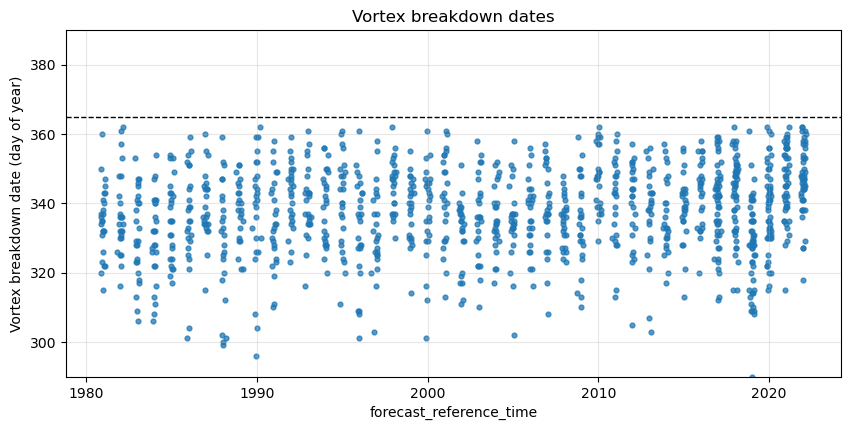

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/climca/people/glattus/Hindcast_data_ready/SEAS5_VortexBreakdown_DOY.csv')
VB = np.mean(data['VB_DOY'])
df = data

df["forecast_reference_time"] = pd.to_datetime(df["forecast_reference_time"])
df["year"] = df["forecast_reference_time"].dt.year

rng = np.random.default_rng(0)
df["year_jitter"] = df["year"] + rng.normal(0, 0.08, size=len(df))

plt.figure(figsize=(10, 4.5))

plt.scatter(
    df["year_jitter"],
    df["VB_DOY"],
    s=12,
    alpha=0.75
)

plt.axhline(365, linestyle="--", color="black", linewidth=1)

plt.ylim(290, 390)

plt.xlabel("forecast_reference_time")
plt.ylabel("Vortex breakdown date (day of year)")
plt.title("Vortex breakdown dates")

plt.grid(alpha=0.3)
plt.show()

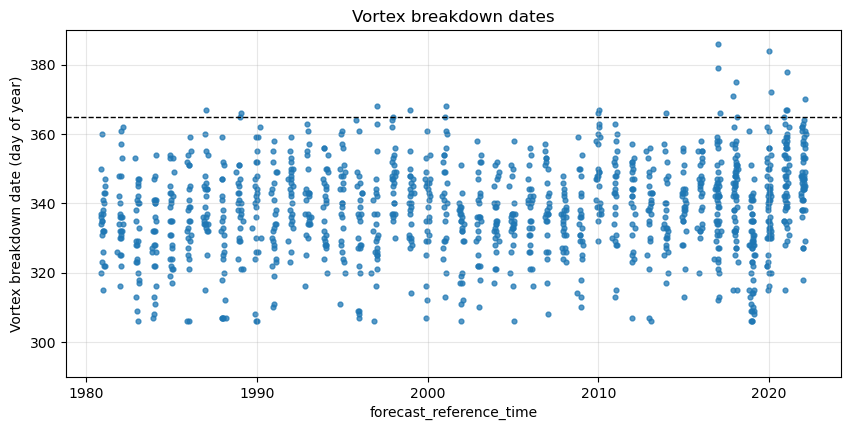

In [ ]:

data = pd.read_csv('/climca/people/glattus/Hindcast_data_ready/SEAS5_VortexBreakdown_DOY_Aug.csv')
VB = np.mean(data['VB_DOY'])
df = data

df["forecast_reference_time"] = pd.to_datetime(df["forecast_reference_time"])
df["year"] = df["forecast_reference_time"].dt.year

rng = np.random.default_rng(0)
df["year_jitter"] = df["year"] + rng.normal(0, 0.08, size=len(df))

plt.figure(figsize=(10, 4.5))

plt.scatter(
    df["year_jitter"],
    df["VB_DOY"],
    s=12,
    alpha=0.75
)

plt.axhline(365, linestyle="--", color="black", linewidth=1)

plt.ylim(290, 390)

plt.xlabel("forecast_reference_time")
plt.ylabel("Vortex breakdown date (day of year)")
plt.title("Vortex breakdown dates")

plt.grid(alpha=0.3)
plt.show()

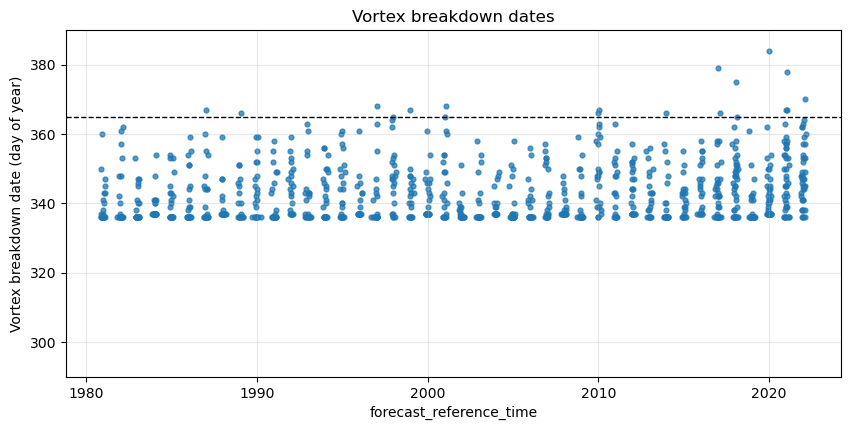

In [30]:

data = pd.read_csv('/home/jmindlin/work/Hindcast/SEAS5_VortexBreakdown_DOY_Jul.csv')
VB = np.mean(data['VB_DOY'])
df = data

df["forecast_reference_time"] = pd.to_datetime(df["forecast_reference_time"])
df["year"] = df["forecast_reference_time"].dt.year

rng = np.random.default_rng(0)
df["year_jitter"] = df["year"] + rng.normal(0, 0.08, size=len(df))

plt.figure(figsize=(10, 4.5))

plt.scatter(
    df["year_jitter"],
    df["VB_DOY"],
    s=12,
    alpha=0.75
)

plt.axhline(365, linestyle="--", color="black", linewidth=1)

plt.ylim(290, 390)

plt.xlabel("forecast_reference_time")
plt.ylabel("Vortex breakdown date (day of year)")
plt.title("Vortex breakdown dates")

plt.grid(alpha=0.3)
plt.show()

   year        VB  VB_DOY_mean_all_members
0  1951 -0.065298               337.712605
1  1952 -0.100988               337.712605
2  1953  0.224743               337.712605
3  1954  0.034158               337.712605
4  1955  0.127547               337.712605


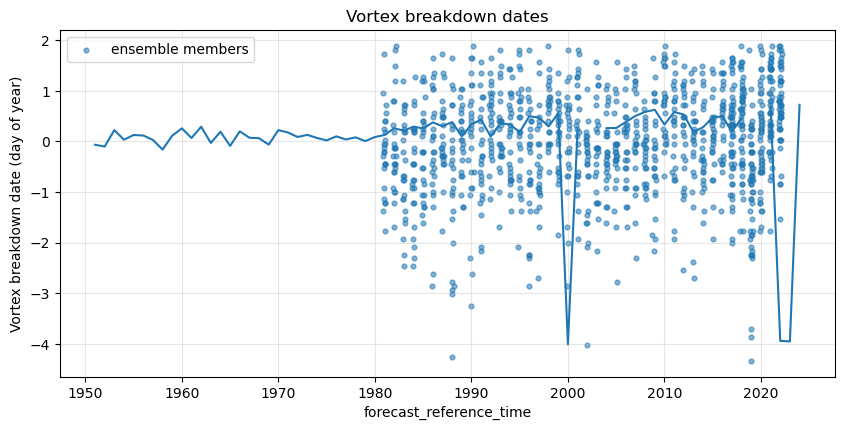

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def standardize(x):
    return (x-np.mean(x))/np.std(x)


# Scatter data: 51 members x years
vb_scatter = data
vb_scatter["forecast_reference_time"] = pd.to_datetime(vb_scatter["forecast_reference_time"])
vb_scatter["year"] = vb_scatter["forecast_reference_time"].dt.year

# Other data
other = data_era5

# keep only year and VB
other = other.rename(columns={"Unnamed: 0": "year"})
other_vb = other[["year", "VB"]].copy()

# add mean value of the hindcast VB_DOY scatters
other_vb["VB_DOY_mean_all_members"] = np.mean(vb_scatter["VB_DOY"])

print(other_vb.head())

# mean of scatters for each year
vb_mean_year = (
    vb_scatter
    .groupby("year", as_index=False)["VB_DOY"]
    .mean()
    .rename(columns={"VB_DOY": "VB_DOY_ens_mean"})
)

# plot
rng = np.random.default_rng(0)
vb_scatter["year_jitter"] = vb_scatter["year"] + rng.normal(0, 0.08, size=len(vb_scatter))

plt.figure(figsize=(10, 4.5))

plt.plot(other_vb["year"],other_vb["VB"])

plt.scatter(
    vb_scatter["year_jitter"],
    standardize(vb_scatter["VB_DOY"]),
    s=12,
    alpha=0.55,
    label="ensemble members"
)

# plt.scatter(
#     vb_mean_year["year"],
#     vb_mean_year["VB_DOY_ens_mean"],
#     s=35,
#     label="ensemble mean"
# )

# plt.axhline(365, linestyle="--", color="black", linewidth=1)


plt.xlabel("forecast_reference_time")
plt.ylabel("Vortex breakdown date (day of year)")
plt.title("Vortex breakdown dates")

plt.grid(alpha=0.3)
plt.legend()
plt.show()